# Testing out Bayesian Optimization on toy examples in a few different dimensions

In [2]:
import numpy as np
from bayes_opt.acquisition import UpperConfidenceBound, ExpectedImprovement
from bayes_opt.acquisition import ProbabilityOfImprovement

In [3]:
import sys
import os
from tqdm.notebook import tqdm # Import tqdm for notebook progress bars
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import re # For sanitizing filenames
from bayes_opt import BayesianOptimization
from bayes_opt.acquisition import ExpectedImprovement, UpperConfidenceBound # Import specific acquisitions
from tqdm.notebook import tqdm # Import tqdm for notebook progress bars
import copy # To deep copy acquisition function if needed
sys.path.append(os.path.abspath('..'))
from venus_ml import generate_shifted_noisy_gaussian, generate_styblinski_tang, BayesOptimizer

## Testing Framework

# Experiments


--- Running Single 5D Shifted Gaussian Experiment (Known Max, Default EI) ---
Using known true maximum for comparison: 1.000000

Starting single optimization run: 30 random, max 300 acquisition steps.
Using Acquisition Function: UpperConfidenceBound (kappa2p58)


Random Exploration:   0%|          | 0/30 [00:00<?, ?it/s]

Acquisition Phase :   0%|          | 0/300 [00:00<?, ?it/s]


--- Single Run Finished ---
Optimization finished after 330 iterations.
Best value found (Observed): 0.960547
Best value found (GP Max):   0.960547
Best parameters found: {'x0': 1.082952136295297, 'x1': -0.1641174109827599, 'x2': 1.3771389650166825, 'x3': 0.8085269908911639, 'x4': -1.7964573423951888}
Difference from Known True Max (1.000000): 0.039453 (3.9453%)
---------------------------
Summary plot saved to toy_bayes/bayesopt_summary_shifted_gaussian_d5_a1.0_n0.0_d5_UpperConfidenceBound_kappa2p58_r30_a300_i330_seed123.png


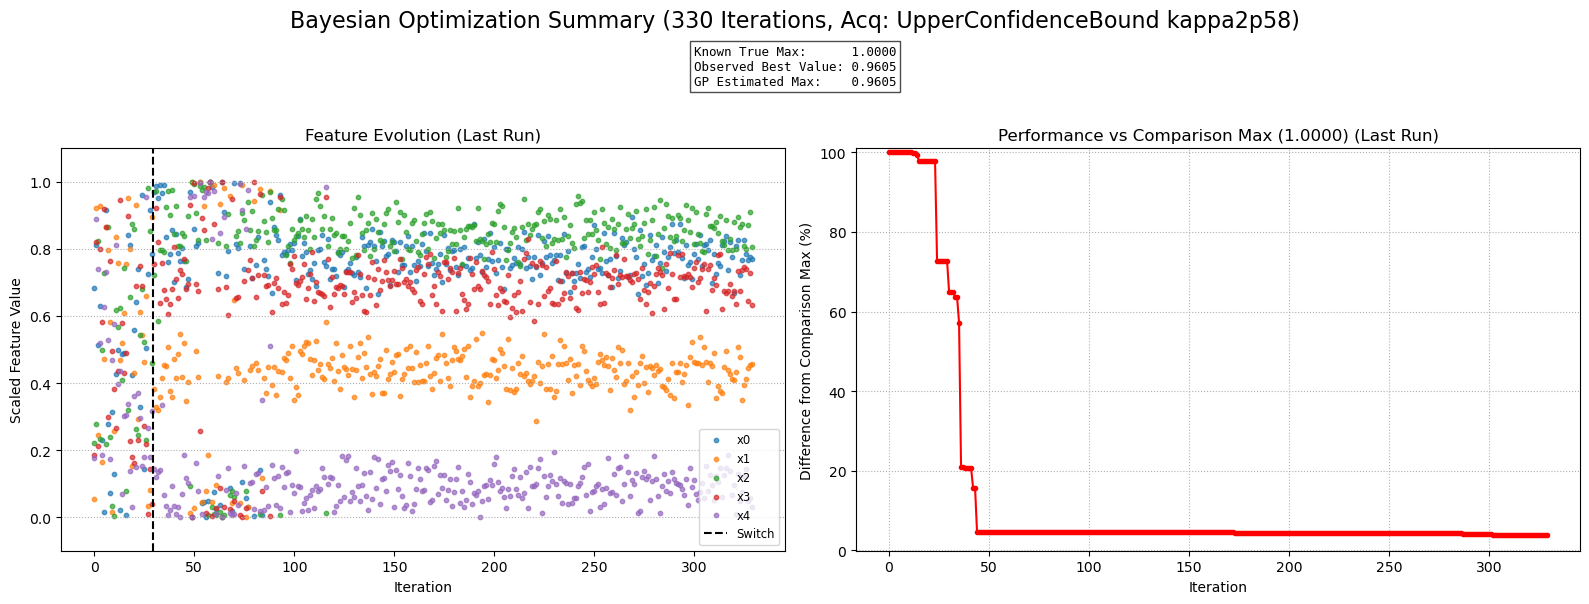

--- Single Experiment Complete ---


In [13]:
import numpy as np
from bayes_opt.acquisition import ExpectedImprovement, UpperConfidenceBound
# Assuming BayesOptimizer class and generate_shifted_noisy_gaussian are defined above

# --- Single 5D Shifted Gaussian Experiment (Known Max) ---

# 1. Setup Problem
dimension_single = 5
gaussian_alpha = 1.0  # Controls peak width (higher is narrower)
gaussian_noise = 0.0   # Standard deviation of noise added (set to 0)
bound_lower = -2.0     # Lower bound for each dimension
bound_upper = 2.0      # Upper bound for each dimension
shift_seed = 42        # Seed for reproducible random shift generation

# 2. Generate the function and bounds
# Let the function generate a random shift within the bounds using the seed
func, pbounds = generate_shifted_noisy_gaussian(
    dim=dimension_single,
    alpha=gaussian_alpha,
    noise=gaussian_noise,
    lower=bound_lower,
    upper=bound_upper,
    shift=None, # Use None for random shift, not 0
    random_state=shift_seed # Add seed for reproducible shift
)

# Determine the known maximum value
# For amplitude=1 (implicit in generate_shifted_noisy_gaussian) and noise=0,
# the maximum value is exactly 1.0 at the shift location.
known_max_value = 1.0

# 3. Instantiate Optimizer (Verbose ON by default)
optimizer_single = BayesOptimizer(
    func=func,
    pbounds=pbounds,
    known_true_max=known_max_value, # <--- Pass the known maximum here
    early_stopping_threshold=0.03,  # Stop if within 2.5% of known max
    early_stopping_patience=2,       # For 2 consecutive iterations
    random_state=123,                # Add seed for optimizer reproducibility
    verbose=True
)

# 4. Define Acquisition Function (Default EI: xi=0.01)
# acquisition_func_single = ExpectedImprovement(xi=0.01)
acquisition_func_single = UpperConfidenceBound(kappa=2.576) # Alternative

# 5. Run the Experiment
# Update print statement to reflect the correct function
print(f"\n--- Running Single {dimension_single}D Shifted Gaussian Experiment (Known Max, Default EI) ---")
single_run_data = optimizer_single.run_experiment(
    acquisition_fn=acquisition_func_single,
    n_random=30,          # Number of initial random points
    n_acq_max=300,         # Maximum number of acquisition steps
    approx_max_samples=10000, # This will be ignored since known_true_max is provided
    plot_summary=True,    # Show the summary plot
    save_plot=True        # Optional: Save the plot with auto-generated name
    # save_filename="gauss_5d_known_max_ei_run" # Optional: Specify custom filename
)
print("--- Single Experiment Complete ---")

